## WORKING ON TITANIC DATASET
# DATA CLEANING AND PREPARATION FOR MAKING PREDICTIVE MODEL

Lets start by importing the neccesary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Now lets load our titanic dataset 

In [3]:
titanic=pd.read_csv(r"C:\Users\ADMIN\Downloads\Titanic-Dataset.csv")
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Now we can see our Dataet preview so lets do some data cleaning by checking for null and duplicated values

In [6]:
a=titanic.isna().sum()
b=titanic.duplicated().sum()
print('The number of null values from each variable is', a)
print('The number of duplicates is ', b)

The number of null values from each variable is PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
The number of duplicates is  0


From this result we can see that the age variables has a lot of null values with the cabin and embarked variable so lets handle the missing values by filling them with their median

In [27]:
titanic['Age'].fillna(titanic['Age'].median(),inplace=True)
titanic

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7792\1223419892.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Age'].fillna(titanic['Age'].median(),inplace=True)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0.0
1,1,1,1,38.0,1,0,71.2833,1.0
2,1,3,1,26.0,0,0,7.9250,0.0
3,1,1,1,35.0,1,0,53.1000,0.0
4,0,3,0,35.0,0,0,8.0500,0.0
...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,0.0
887,1,1,1,19.0,0,0,30.0000,0.0
888,0,3,1,28.0,1,2,23.4500,0.0
889,1,1,0,26.0,0,0,30.0000,1.0


Now that the age nullvalues has been filled lets remove some variables that are not numerical

In [18]:
titanic.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

In [19]:
titanic

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


Now we have important variables hereso lets check how many values are in the embarked variable

In [20]:
titanic['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

So it only has three letters this can be converted to numerical values with the sex variable

In [21]:
Numerical_sex=titanic['Sex'].map({'male':0,'female':1})
titanic['Sex']= Numerical_sex

In [23]:
Numerical_embarked=titanic['Embarked'].map({'S':0,'C':1,'Q':2})
titanic['Embarked']=Numerical_embarked

In [28]:
titanic

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0.0
1,1,1,1,38.0,1,0,71.2833,1.0
2,1,3,1,26.0,0,0,7.9250,0.0
3,1,1,1,35.0,1,0,53.1000,0.0
4,0,3,0,35.0,0,0,8.0500,0.0
...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,0.0
887,1,1,1,19.0,0,0,30.0000,0.0
888,0,3,1,28.0,1,2,23.4500,0.0
889,1,1,0,26.0,0,0,30.0000,1.0


Now that theyve been converted to numerical values lets check their correlation values 

In [32]:
titanic.corr()['Survived'].sort_values(ascending=False)

Survived    1.000000
Sex         0.543351
Fare        0.257307
Embarked    0.108669
Parch       0.081629
SibSp      -0.035322
Age        -0.064910
Pclass     -0.338481
Name: Survived, dtype: float64

In [33]:
titanic

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0.0
1,1,1,1,38.0,1,0,71.2833,1.0
2,1,3,1,26.0,0,0,7.9250,0.0
3,1,1,1,35.0,1,0,53.1000,0.0
4,0,3,0,35.0,0,0,8.0500,0.0
...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,0.0
887,1,1,1,19.0,0,0,30.0000,0.0
888,0,3,1,28.0,1,2,23.4500,0.0
889,1,1,0,26.0,0,0,30.0000,1.0


Now lets perform some univariate amd bivariate analysis

In [41]:
survived_count=titanic['Survived'].value_counts()
survived_count

Survived
0    549
1    342
Name: count, dtype: int64

From the value count we can see that the number of people that died is bigger than the number of people that survived Lets visualize this

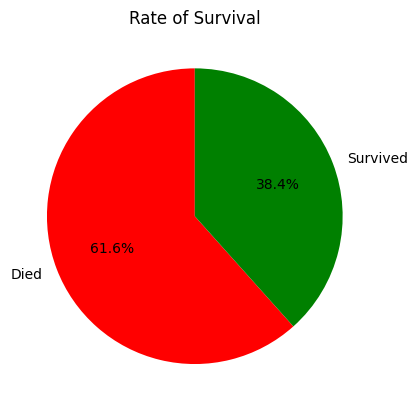

In [50]:
plt.pie(x=survived_count,colors=['red','green'],labels=['Died','Survived'],autopct='%1.1f%%',startangle=90)
plt.title('Rate of Survival')
plt.show()


From this we can see that the rate at which people died is bigger than the rate at which they survived now lets check if the ship was filled the 1st class or second or third

In [54]:
Pclass_count=titanic['Pclass'].value_counts()
Pclass_count

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

From this we can see that the ship was filled with third class passengers so lets visalize the percentage

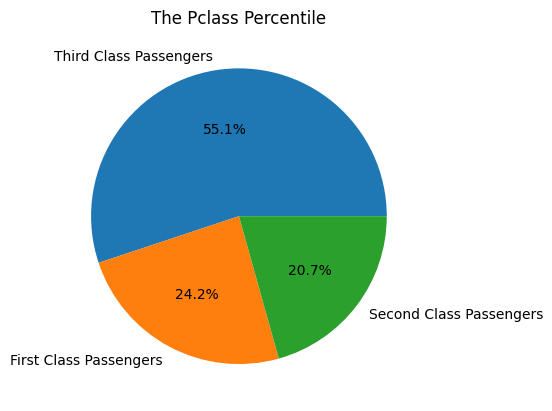

In [58]:
plt.pie(x=Pclass_count,labels=['Third Class Passengers','First Class Passengers','Second Class Passengers'],autopct='%1.1f%%')
plt.title('The Pclass Percentile')
plt.show()

So from this visualized chart we can see that the ship was full of thurd class passengers so thats univariate analysis lets jump into bivariate by seeing how many people survived from each class

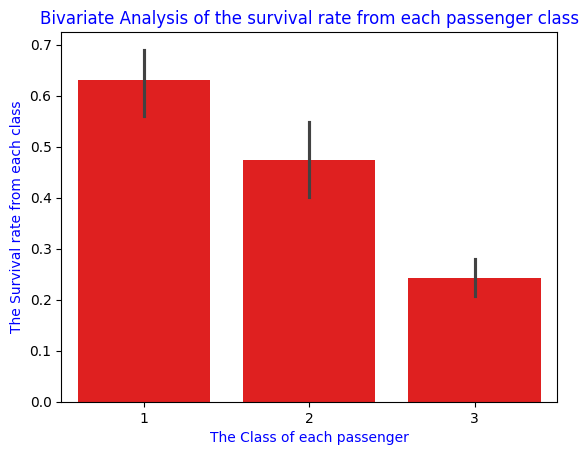

In [68]:
sns.barplot(x='Pclass',y='Survived',data=titanic,color='red')
plt.xlabel('The Class of each passenger',color='blue')
plt.ylabel('The Survival rate from each class',color='blue')
plt.title('Bivariate Analysis of the survival rate from each passenger class',color='blue')
plt.show()


From this visualized chart here we can see that people survived more at the first class passenger seat now that we are done with this lets identify some trends for our model development

In [70]:
titanic.corr()['Survived'].sort_values(ascending=False)

Survived    1.000000
Sex         0.543351
Fare        0.257307
Embarked    0.108669
Parch       0.081629
SibSp      -0.035322
Age        -0.064910
Pclass     -0.338481
Name: Survived, dtype: float64

From this we can see the correlation of all variables with the servived variables and we can bodly say that sex is the most massive factor in buildig our predictive model now we can confirm it ny this bivariate analysis

<Axes: xlabel='Pclass', ylabel='Survived'>

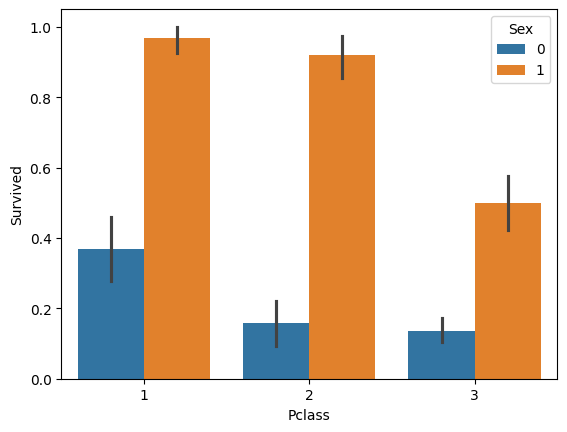

In [71]:
sns.barplot(x='Pclass',y='Survived',hue='Sex',data=titanic)

From this we can see that the females survived most across each passenger class this is to say how much impact/role sex variable plays